<a href="https://colab.research.google.com/github/annacalvetti/market-microstructure-alpha-decoder./blob/main/Micro_Market_Alpha_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

def compute_continuous_theoretical_alpha(n,shift=.5):
  mle_theoretical_error_rate=norm.sf(latent_alpha_shift * np.sqrt(n_range))
  return mle_theoretical_error_rate
def compute_binary_theoretical_alpha(n,shift=.5):
  p=norm.cdf(shift)
  p_error=np.zeros(len(n))
  for i, num_signals in enumerate(n):
    if num_signals % 2==1: #odd number majority rule
      k=int(np.ceil(num_signals/2)) #rounds up to whole number
      p_error[i]=binom.cdf(k-1,num_signals,p)
  return p_error

In [2]:
def simulate_continuous_vwap_feed(n_feeds=39,shift=.5,target_error=200):
  #runs monte carlo with stopping rule (200 errors) for continuous feeds
  errors=0
  total_runs=0
  #generate 300,000 rows to ensure 200 errors observation
  noise=np.random.normal(0,1, size=(300000,n_feeds))
   #300000 rows, 39 columns for sensors
  market_signals=latent_alpha_shift+noise
  sample_means=np.mean(market_signals,axis=1)
  error_bool=sample_means<0 #booleant
  error_index=np.where(error_bool)[0]
   #finds where it is true, and gives 1st element of that array
  idx_200=error_index[target_error-1]
  total_trials=idx_200+1
   #simulations run up to and including 200th error
  mle_decoding_error_rate=target_error/total_trials
  return mle_decoding_error_rate

In [3]:
def simulate_quantized_lob_feed(n_indicators=61,shift=.5,target_error=200):
  #runs vectorized monte carlo trials with stopping rule for binary indicators
  microstructure_noise=np.random.normal(0,1, size=(300000,n_indicators))  #300000 rows, n columns for indictarors
  raw_shift =microstructure_delta +microstructure_noise
  quantized_lob_bits=raw_shift>=0
  positive_indicator_count=np.sum(quantized_lob_bits,axis=1)
  majority_threshold=int(np.floor(n_indicators/2))
  decoding_errors= positive_indicator_count<=majority_threshold
  error_index=np.where(decoding_errors)[0]
  total_simulation_trials=error_index[target_error-1] +1 #simulations run up to and including 200th error
  empircal_binary_error_rate=target_error/total_simulation_trials
  return empircal_binary_error_rate

In [4]:
def run_parity_paradox_optimization(n_indicators, shift=.5):
  #optmizes alpha decoder decision boundary (Tau) to resolve parity
  tauvect=np.arange(0,.4,.001)
  besterror=1.0
  best_tau=0.0
  N= n_indicators+1 #even
  for tau in tauvect:
    p1=1-norm.cdf(tau-shift)
    p0=1-norm.cdf(tau+shift)
    u=np.arange(0,N+1)
    PMF1=binom.pmf(u,N,p1)
    PMF0=binom.pmf(u,N,p0)

    decide = PMF1>=PMF0
    error1=np.sum(PMF1[~decide])
    error2=np.sum(PMF0[decide])
    error=.5*error1+.5*error2
    if error<besterror:
      besterror=error
      best_tau=tau
  return best_tau, besterror
  print('Optimal Parity Error Found via PMF Intersection:', besterror)
  print('Optimal Microstructure Threshold (Tau):', best_tau)

Text(0.5, 1.0, 'Alpha Decoder Threshold Optimization via Binomial PMF Minimization')

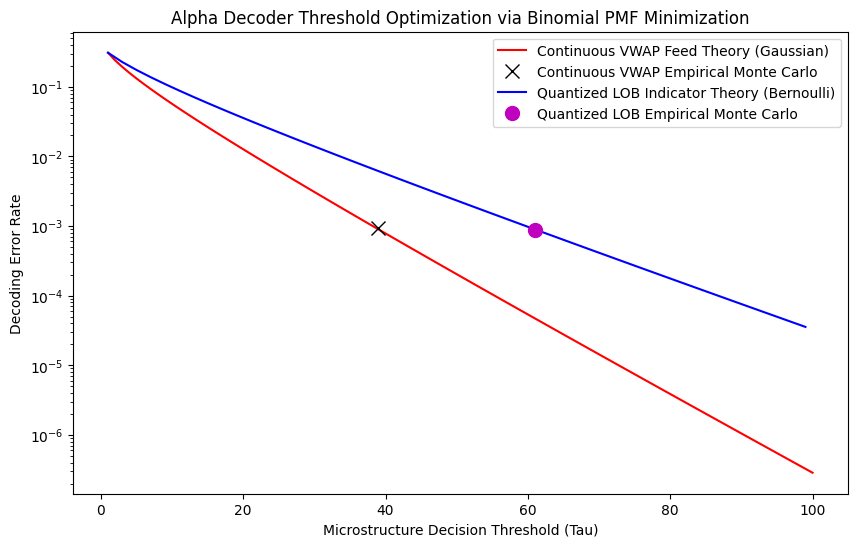

In [5]:
#Execution
#generate ranges
n_range=np.arange(1,101)
n_odd_range=np.arange(1,101,2)

#theoretical bounds
latent_alpha_shift=.5
microstructure_delta=.5
p_theoretical_continuous = compute_continuous_theoretical_alpha(n_range)
p_theoretical_binary = compute_binary_theoretical_alpha(n_odd_range)

#run empircal simulations
emp_continuous_err = simulate_continuous_vwap_feed(n_feeds=39)
emp_binary_err = simulate_quantized_lob_feed(n_indicators=61,shift=.5,target_error=200)

#run threshold optimization for parity paradox
best_tau, opt_err = run_parity_paradox_optimization(n_indicators=61)

#plot
plt.figure(figsize=(10, 6))
plt.semilogy(n_range, p_theoretical_continuous, 'r-', label='Continuous VWAP Feed Theory (Gaussian)')
plt.semilogy(39, emp_continuous_err, 'kx', markersize=10, label='Continuous VWAP Empirical Monte Carlo')

plt.semilogy(n_odd_range, p_theoretical_binary, 'b-', label='Quantized LOB Indicator Theory (Bernoulli)')
plt.semilogy(61, emp_binary_err, 'mo', markersize=10, label='Quantized LOB Empirical Monte Carlo')
plt.legend()
plt.xlabel('Microstructure Decision Threshold (Tau)')
plt.ylabel('Decoding Error Rate')
plt.title('Alpha Decoder Threshold Optimization via Binomial PMF Minimization')
